In [61]:
#LAB3
#Kwantsimah Orleans Boham
#12912028

In [62]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


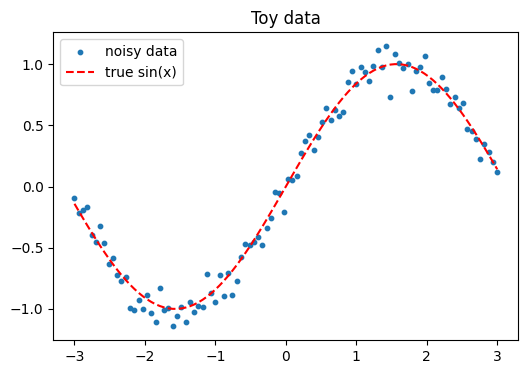

In [63]:
#Section 1
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize = (6, 4))
plt.scatter(x, y, s=10, label = "noisy data")
plt.plot(x, np.sin(x), 'r--', label = "true sin(x)")
plt.legend()
plt.title("Toy data")
plt.show()

In [64]:
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

lr = 0.1
n_steps = 200
losses = []

for step in range(n_steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))

    w    -= lr * dw
    b    -= lr * db

print(len(losses), losses[:5], losses[-5:])

print(f"Final w = {w: .4f}, b= {b: .4f}, loss = {losses[-1]:.4f}")

200 [np.float64(0.9032945639381899), np.float64(0.302438028591318), np.float64(0.21186231534876973), np.float64(0.1981220033943185), np.float64(0.19598232605594412)] [np.float64(0.1954517971396205), np.float64(0.1954517971396205), np.float64(0.1954517971396205), np.float64(0.1954517971396205), np.float64(0.1954517971396205)]
Final w =  0.3390, b= -0.0104, loss = 0.1955


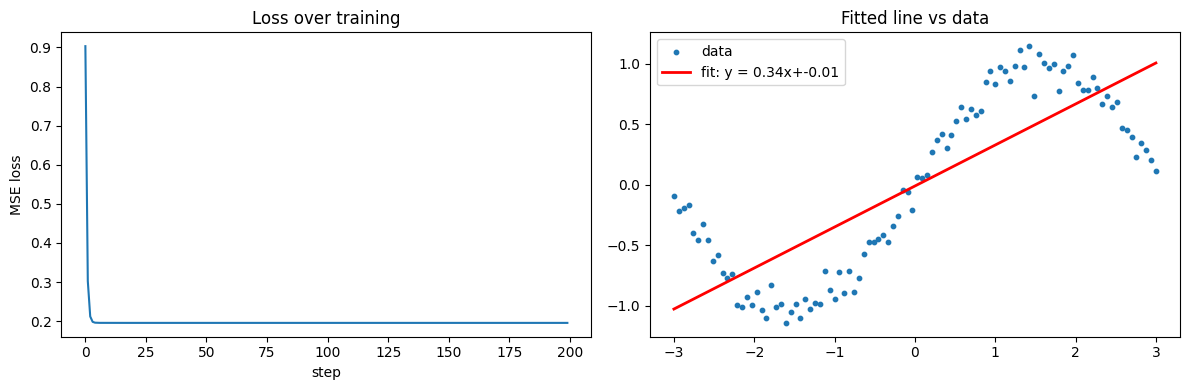

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


#loss curve
axes[0].plot(losses)
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Loss over training")

axes[1].scatter(x, y, s=10, label = "data")
axes[1].plot(x, w * x + b, 'r-', linewidth = 2, label = f"fit: y = {w:.2f}x+{b:.2f}")
axes[1].legend()
axes[1].set_title("Fitted line vs data")

plt.tight_layout()
plt.show()

![Derivative](https://raw.githubusercontent.com/kwantsimahschool/ai-course-lab3/refs/heads/main/photo_2026-07-28_22-45-54.jpg)

put the second part in two simple sentences

This is underfitting. The model plateaus because it's already found its best possible line, not because it needs more training.

A single neuron with no activation can only compute wx + b, which is a straight line no matter what values w and b take, so it can never bend to match the curve of sin(x).

In [66]:
#SECTION 1.2
x2 = x.reshape(-1, 1)
y2 = y.reshape(-1, 1)

np.random.seed(0)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

def forward(x2, W1, b1, W2, b2):
    z1 = x2 @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    return z1, h, y_hat

lr = 0.05
n_steps = 3000
losses = []

for step in range(n_steps):
  z1 = x2 @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y2) ** 2)
  losses.append(loss)

  d_yhat = 2 * (y_hat - y2) / len(y2)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis = 0)
  dh = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x2.T @ dz1
  db1 = dz1.sum(axis = 0)

#update
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

print(f"Final loss:  {losses[-1]:.5f}")

Final loss:  0.01299


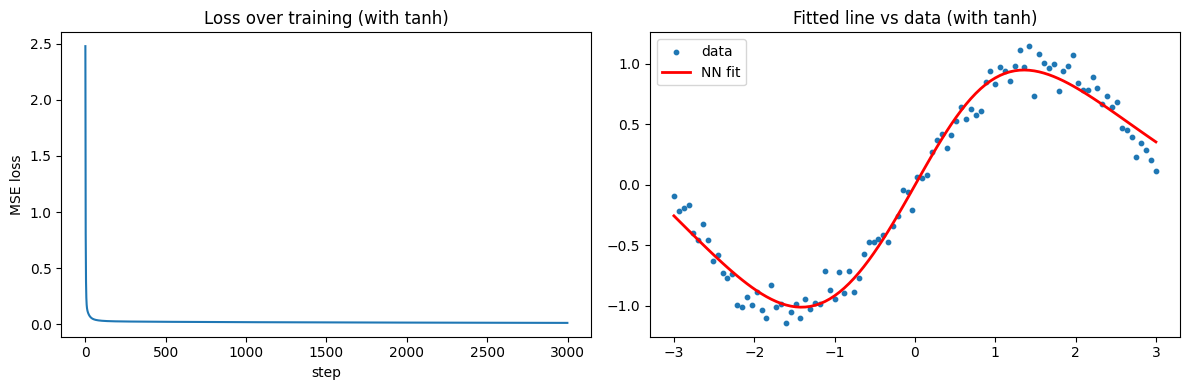

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#loss
axes[0].plot(losses)
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Loss over training (with tanh)")

#recompute final prediction for plotting
_, _, y_hat_final = forward(x2, W1, b1, W2, b2)

axes[1].scatter(x, y, s=10, label = "data")
axes[1].plot(x, y_hat_final, 'r-', linewidth=2, label = "NN fit")
axes[1].legend()
axes[1].set_title("Fitted line vs data (with tanh)")

plt.tight_layout()
plt.show()

In [68]:
##plot after removing tanh
np.random.seed(0)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.05
n_steps = 3000
losses_no_tanh = []

for step in range(n_steps):
  z1 = x2 @ W1 + b1
  h = z1
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y2) ** 2)
  losses_no_tanh.append(loss)

  d_yhat = 2 * (y_hat - y2) / len(y2)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis = 0)
  dh = d_yhat @ W2.T
  dz1 = dh
  dW1 = x2.T @ dz1
  db1 = dz1.sum(axis = 0)

  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

print(f"Final loss:  {losses_no_tanh[-1]:.5f}")


Final loss:  0.19545


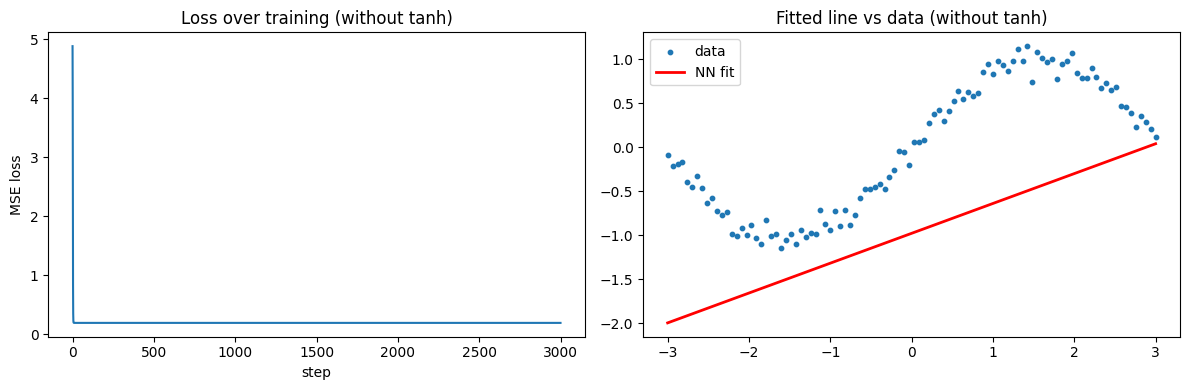

In [69]:
fig, axes  = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses_no_tanh)
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("Loss over training (without tanh)")

z1 = x2 @ W1 + b1
h = z1
y_hat_final = h @ W2 + b


axes[1].scatter(x, y, s=10, label = "data")
axes[1].plot(x, y_hat_final, 'r-', linewidth=2, label = "NN fit")
axes[1].legend()
axes[1].set_title("Fitted line vs data (without tanh)")

plt.tight_layout()
plt.show()

a. y^=(xW1+b1)W2+b2=x(W1W2)+(b1W2+b2)

Multiplying x by W1 then W2 is the same as multiplying x by one combined matrix W1W2, so two "linear layers" are really just one linear layer wearing a disguise.

b. Each neuron learned its own bent tanh curve (a different sigmoid-shaped bend, since each has different weights/bias), and the output layer added weighted copies of these 8 curves together to build the S-shape of sine.

c. Backpropagation is the chain rule applied automatically, layer by layer, to compute how much each weight contributed to the error.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_546/3906949597.py:14: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y2) ** 2)
/tmp/ipykernel_546/3906949597.py:20: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_546/3906949597.py:21: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


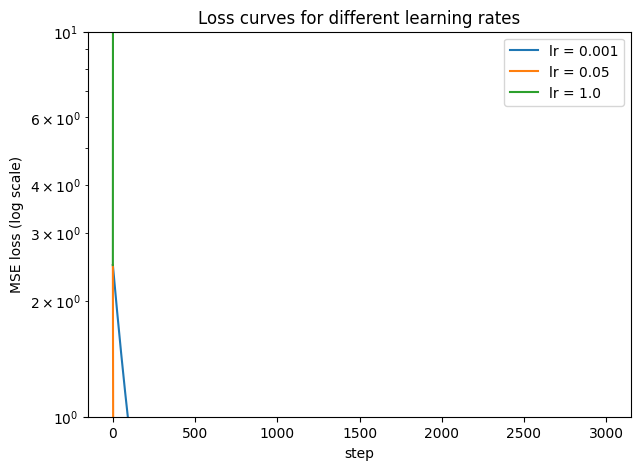

0.04111099454524656 0.012990299804299355 nan


In [70]:
#SECTION 1.3
def train_toy(lr, steps = 3000):
  np.random.seed(0)
  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.random.randn(8) * 0.5
  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.random.randn(1) * 0.5

  losses = []
  for step in range(steps):
    z1 = x2 @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y2) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y2) / len(y2)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis = 0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x2.T @ dz1
    db1 = dz1.sum(axis = 0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

  return losses

losses_001  = train_toy(lr = 0.001)
losses_005  = train_toy(lr = 0.05)
losses_01   = train_toy(lr = 1.0)

plt.figure(figsize = (7, 5))
plt.plot(losses_001, label = "lr = 0.001")
plt.plot(losses_005, label = "lr = 0.05")
plt.plot(losses_01, label = "lr = 1.0")

plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE loss (log scale)")
plt.title("Loss curves for different learning rates")
plt.legend()
plt.show()

print(losses_001[-1], losses_005[-1], losses_01[-1])

lr = 1e-4 drops very slowly — the steps are so tiny that after 50 epochs it's still far from the best loss.

lr = 1e-3 drops smoothly and quickly to a low, stable loss — this is the well-tuned middle ground.

lr = 1e-1 bounces around or spikes up instead of settling down — the steps are too big to land near the minimum.

Each gradient step is a jump proportional to lr, so a huge lr makes the jump overshoot past the minimum to the other side of the loss curve.

Once you overshoot, the new gradient points back the other way, so the next jump overshoots again in the opposite direction. The loss zig-zags instead of settling down.

In [71]:
#SECTION 2.1
from sklearn.preprocessing import LabelEncoder

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
df = pd.read_csv(OBESITY_URL)
df.head()

binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
  df[col] = df[col].map({"yes": 1, "no": 0})

df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

freq_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df["CAEC"] = df["CAEC"].map(freq_map)
df["CALC"] = df["CALC"].map(freq_map)

df = pd.get_dummies(df, columns = ["MTRANS"], drop_first = False)

print(df.isnull().sum().sum())


target_encoder = LabelEncoder()
df["NObeyesdad"] = target_encoder.fit_transform(df["NObeyesdad"])

print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

X = df.drop("NObeyesdad", axis = 1)
y = df["NObeyesdad"].values.astype(np.int64)

print(X.shape, y.shape)

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.4, stratify = y, random_state = RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = RANDOM_STATE)

print(X_train.shape, X_val.shape, X_test.shape)


0
{'Insufficient_Weight': np.int64(0), 'Normal_Weight': np.int64(1), 'Obesity_Type_I': np.int64(2), 'Obesity_Type_II': np.int64(3), 'Obesity_Type_III': np.int64(4), 'Overweight_Level_I': np.int64(5), 'Overweight_Level_II': np.int64(6)}
(2111, 20) (2111,)
(1266, 20) (422, 20) (423, 20)


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [73]:
X_train_t = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_t = torch.tensor(y_train, dtype = torch.long)

X_val_t = torch.tensor(X_val_scaled, dtype = torch.float32)
y_val_t = torch.tensor(y_val, dtype = torch.long)

X_test_t = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_t = torch.tensor(y_test, dtype = torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_ds, batch_size = 32, shuffle = False)
test_loader = DataLoader(test_ds, batch_size = 32, shuffle = False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape, xb.dtype, yb.dtype)

torch.Size([32, 20]) torch.Size([32]) torch.float32 torch.int64


1. It's faster — the integer just points straight to the right class, no need for a big vector of mostly zeros.

2. Random forests just ask "above or below this number?" so scale doesn't matter. Neural nets use the actual feature value in their math (x is right there in the gradient), so a feature with huge numbers pushes its weight around much more than a feature with small numbers, even if both matter equally.

3. It mixes up the training examples into new batches each epoch, so the model doesn't learn any accidental order-based patterns and training goes more smoothly.

In [74]:
#SECTION 2.2

class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes =(64, 32), n_classes =7):
    super().__init__()
    layers = []
    prev_size = input_dim

    for h in hidden_sizes:
      layers.append(nn.Linear(prev_size, h))
      layers.append(nn.ReLU())
      prev_size = h

    layers.append(nn.Linear(prev_size, n_classes))
    self.net = nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)



In [75]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X_train.shape[1]

model = FeedForwardNet(input_dim = input_dim, hidden_sizes = (64, 32), n_classes = 7)
model = model.to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable: {total_params}")

first_layer_params = input_dim * 64 + 64
print(f"First layer params (hand calculated): {first_layer_params}")

first_linear = model.net[0]
print(first_linear.weight.shape, first_linear.bias.shape)
manual_count = first_linear.weight.numel() + first_linear.bias.numel()
print(f"PyTorch's actual first-layer count: {manual_count}")

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable: 3655
First layer params (hand calculated): 1344
torch.Size([64, 20]) torch.Size([64])
PyTorch's actual first-layer count: 1344


Layer 1 (input → 64): input_dim * 64 + 64
Layer 2 (64 → 32): 64 * 32 + 32 = 2080
Output layer (32 → 7): 32 * 7 + 7 = 231

2. ReLU is faster to compute and doesn't flatten out for large positive inputs the way tanh does, so gradients stay stronger and training is quicker on bigger networks.

3. What happens if you remove the ReLUs:
The whole network collapses into one big linear function, so it becomes no more powerful than a single linear layer


In [76]:
#SECTION 2.3
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 50
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

best_val_acc = 0.0

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
      for xb, yb in loader:
          xb, yb = xb.to(DEVICE), yb.to(DEVICE)
          logits = model(xb)
          loss = criterion(logits, yb)
          total_loss += loss.item() * xb.size(0)
          preds = logits.argmax(dim=1)
          correct += (preds == yb).sum().item()
          total += xb.size(0)
    return total_loss / total, correct / total

for epoch in range(n_epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_loader)
    val_loss, val_acc = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:3d}/{n_epochs} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch   1/50 | train_loss=1.7059 train_acc=0.4107 | val_loss=1.7057 val_acc=0.3934
Epoch   2/50 | train_loss=1.3854 train_acc=0.5711 | val_loss=1.4034 val_acc=0.5498
Epoch   3/50 | train_loss=1.1018 train_acc=0.6374 | val_loss=1.1471 val_acc=0.6114
Epoch   4/50 | train_loss=0.8741 train_acc=0.7117 | val_loss=0.9384 val_acc=0.7156
Epoch   5/50 | train_loss=0.7247 train_acc=0.7472 | val_loss=0.8161 val_acc=0.7251
Epoch   6/50 | train_loss=0.6194 train_acc=0.7899 | val_loss=0.7412 val_acc=0.7559
Epoch   7/50 | train_loss=0.5375 train_acc=0.8239 | val_loss=0.6799 val_acc=0.7820
Epoch   8/50 | train_loss=0.4692 train_acc=0.8610 | val_loss=0.6259 val_acc=0.8128
Epoch   9/50 | train_loss=0.4126 train_acc=0.8784 | val_loss=0.5802 val_acc=0.8175
Epoch  10/50 | train_loss=0.3653 train_acc=0.9036 | val_loss=0.5442 val_acc=0.8246
Epoch  11/50 | train_loss=0.3278 train_acc=0.9100 | val_loss=0.5190 val_acc=0.8507
Epoch  12/50 | train_loss=0.2968 train_acc=0.9155 | val_loss=0.4934 val_acc=0.8389
Epoc

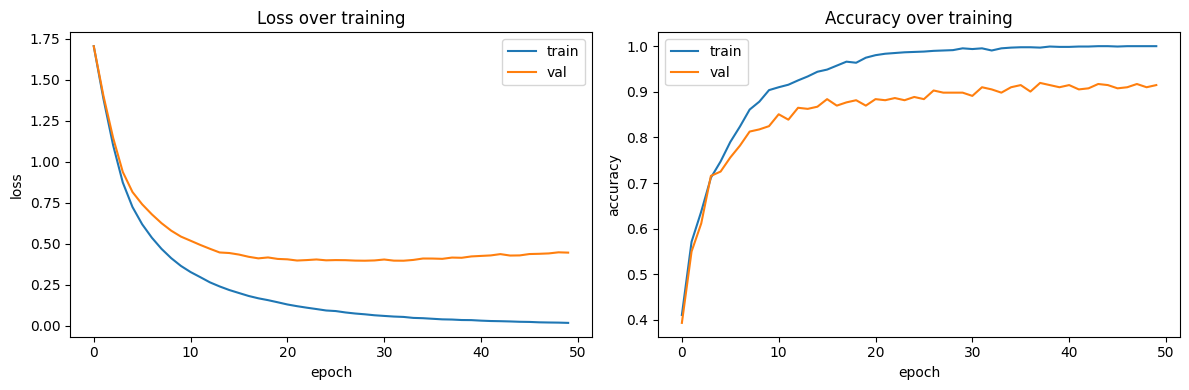

1.0 0.9146919431279621
0.01760007759135387 0.4462807627297691


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Loss over training")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy over training")
axes[1].legend()

plt.tight_layout()
plt.show()

print(history["train_acc"][-1], history["val_acc"][-1])
print(history["train_loss"][-1], history["val_loss"][-1])

1. Mapping PyTorch lines to NumPy lines:

logits = model(xb) = forward pass
loss = criterion(logits, yb) = loss
loss.backward() = gradient computation
optimizer.step() = the update rule


2. Train loss is 0.018, very low, while val loss is 0.45, much higher.

It is overfitting. The model has essentially memorized the training set but performs noticeably worse on data it hasn't seen. The large gap between train and val on both metrics is the signature.

3. PyTorch adds new gradients on top of old ones by default instead of replacing them. Without zeroing, gradients from previous batches would pile up and corrupt the updates, making training unstable or wrong.

In [81]:
class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes =(64, 32), n_classes =7, dropout = 0.0):
    super().__init__()
    layers = []
    prev_size = input_dim
    for h in hidden_sizes:
        layers.append(nn.Linear(prev_size, h))
        layers.append(nn.ReLU())

        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        prev_size = h
    layers.append(nn.Linear(prev_size, n_classes))
    self.net = nn.Sequential(*layers)

  def forward(self, x):
      return self.net(x)

In [82]:
def run_experiment(hidden_sizes = (64, 32), lr = 1e-3, batch_size= 32, epochs = 50, dropout=0.0):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = FeedForwardNet(input_dim = input_dim, hidden_sizes = hidden_sizes, n_classes = 7, dropout=dropout).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    def evaluate(loader):
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
          for xb, yb in loader:
              xb, yb = xb.to(DEVICE), yb.to(DEVICE)
              logits = model(xb)
              loss = criterion(logits, yb)
              total_loss += loss.item() * xb.size(0)
              preds = logits.argmax(dim=1)
              correct += (preds == yb).sum().item()
              total += xb.size(0)
        return total_loss / total, correct / total
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(train_loader)
        val_loss, val_acc = evaluate(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

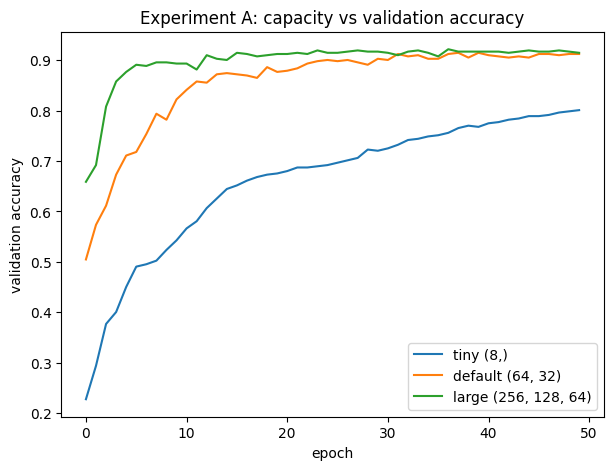

In [83]:
history_tiny = run_experiment(hidden_sizes=(8,), epochs = 50)
history_small = run_experiment(hidden_sizes=(64, 32), epochs = 50)
history_large = run_experiment(hidden_sizes=(256, 128, 64), epochs = 50)

plt.figure(figsize=(7,5))
plt.plot(history_tiny["val_acc"], label="tiny (8,)")
plt.plot(history_small["val_acc"], label="default (64, 32)")
plt.plot(history_large["val_acc"], label="large (256, 128, 64)")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Experiment A: capacity vs validation accuracy")
plt.legend()
plt.show()

In [ ]:
#section2.5
import time
best_model = FeedForwardNet(input_dim=X_train_scaled.shape[1], hidden_sizes=(64, 32), n_classes=7, dropout = 0.0).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt"), map_location =DEVICE)
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
  for xb, yb in test_loader:
    xb = xb.to(DEVICE)
    logits = best_model(xb)
    preds = logits.argsmax(dim=1).cpu().numpy()

    all_preds.append(preds)
    all_labels.append(yb.numpy())

y_preds = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

from sklearn.metrics import accuracy_score, f1_score, classification_report

test_acc = accuracy_score(test_acc, y_preds)
test_macro_f1 = f1_score(y_true, y_preds, average='macro')

print(f"Test Accuracy: (test_acc:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_encoder.classes_))

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=target_encoder.classes_,
    xticks_rotation=45,
    ax=ax,
    cmap="Blues"
)
plt.title("Test set confusion matrix")
plt.tight_layout()
plt.show()

nn_test_acc = accuracy_score(y_true, y_pred)
nn_test_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_macro_f1:.4f}")
print()
print(classification_report(y_true, y_preds, target_names=target_encoder.classes_))

nn_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)
start = time.time()
_ = run_experiment(hidden_sizes=(64, 32), epochs=50)
nn_train_time = time.time() - start

rf_test_acc =
rf_test_f1 =
rf_train_time =
rf_n_trees =

comparison = pd.DataFrame({
    "Model": ["Random Forest (Lab 2)", "Neural Network (this lab)"],
    "Test Accuracy": [rf_test_acc, test_acc],
    "Test Macro-F1": [rf_test_f1, test_macro_f1],
    "Training Time (s)": [rf_train_time, nn_train_time],
    "Params / Trees": [rf_n_trees, nn_params],
})

#section 3
1. loss.backward() walks backward through the network applying the chain rule at each layer, figuring out how much each weight contributed to the final error.

It stores those contributions as gradients on every parameter, without touching the weights yet.

optimizer.step() then takes those stored gradients and nudges each weight a small step in the direction that reduces the loss.

2. Learning rate. It has the biggest effect on whether training works at all, and most other hyperparameters only matter once the learning rate is roughly right.

3. The biggest gap showed up in Experiment C, with the large network  trained without dropout, train accuracy climbed near 100% while val accuracy lagged behind. Adding dropout=0.3 closed that gap the most, since it stopped the network from over-relying on specific neurons and forced it to learn more generalizable patterns.

4. An MLP treats every pixel as a totally separate, unrelated feature, so it has to relearn from scratch for every part of the image, wasting huge numbers of parameters. A better architecture should have some form of local weight-sharing — using the same small set of weights to scan across nearby pixels, so it can detect a pattern like an edge or shape no matter where it appears in the image.